In [1]:
import random
import numpy as np
import torch
import os
import matplotlib.pyplot as plt
import torch
from model import SegFormerMultiTask
from Dataloader import (
    BUSIDataset,
    prepare_busi_dataset,
    get_distribution
) 
from torch.utils.data import DataLoader
import cv2
import pandas as pd
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

import seaborn as sns


========== Dataset Statistics ==========

Train Size : 546
Counter({'benign': 306, 'malignant': 147, 'normal': 93})

Validation Size : 117
Counter({'benign': 65, 'malignant': 32, 'normal': 20})

Test Size : 117
Counter({'benign': 66, 'malignant': 31, 'normal': 20})

Displaying TRAIN samples...


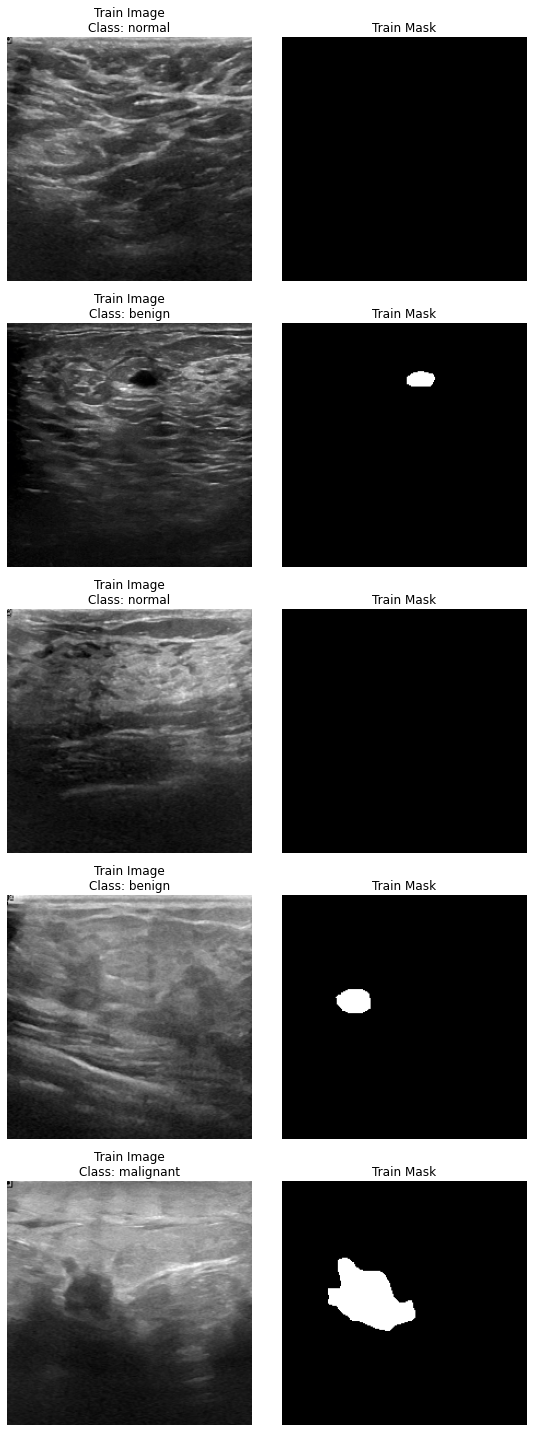


Displaying VALIDATION samples...


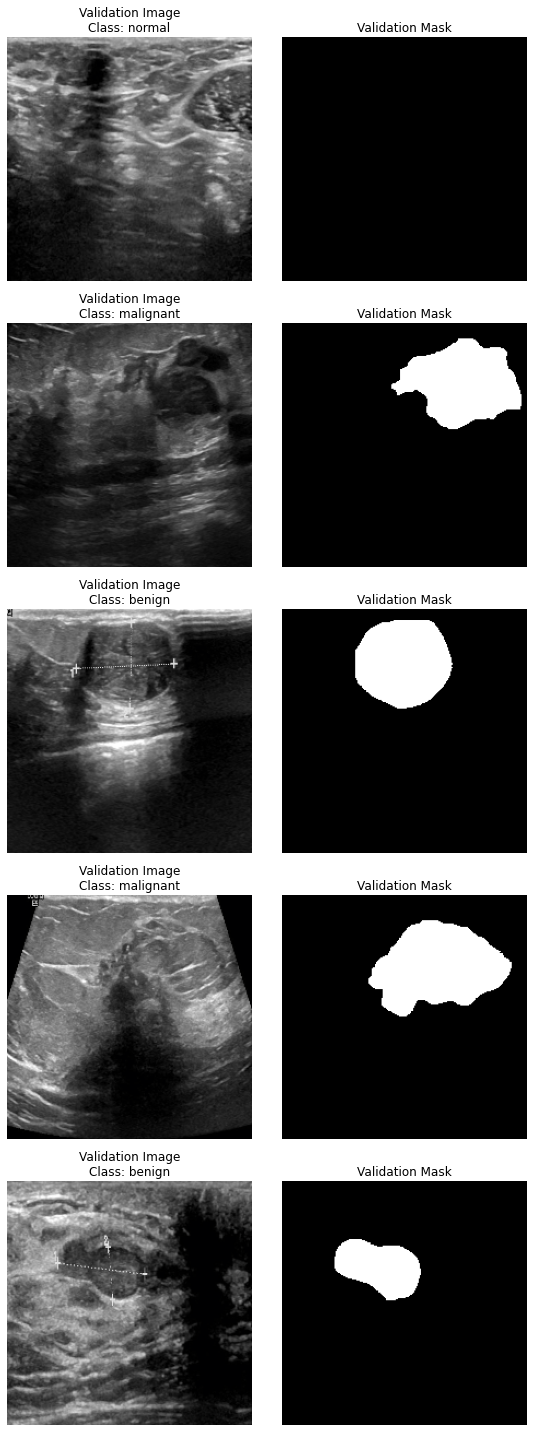


Displaying TEST samples...


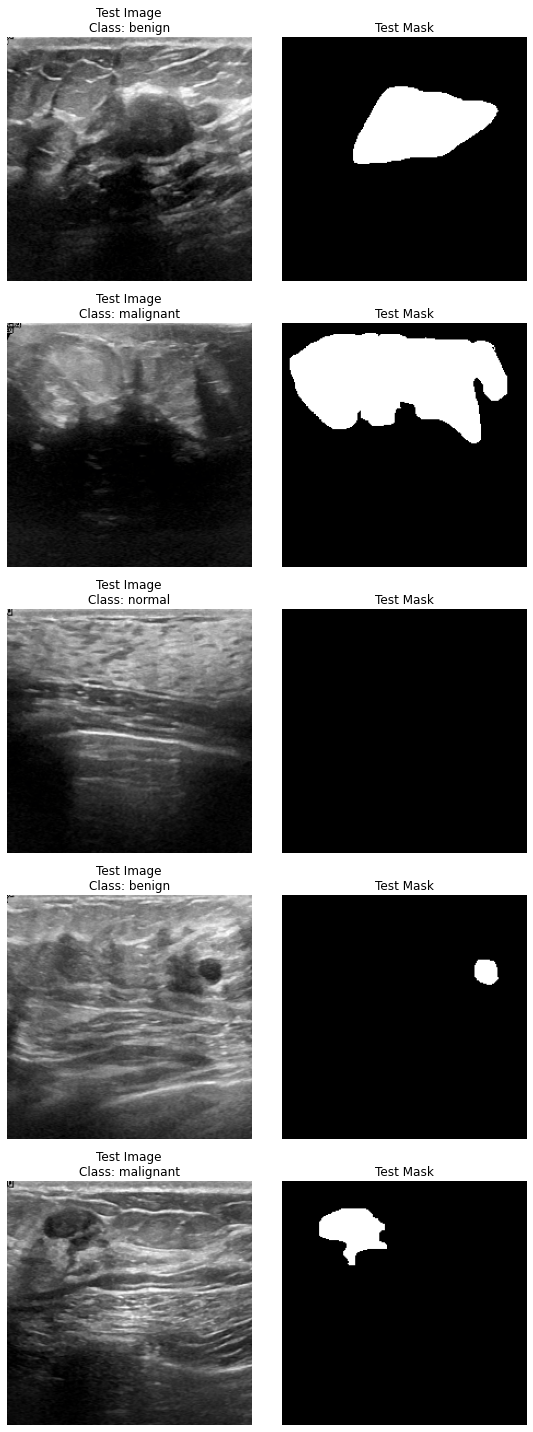

In [2]:


# =====================================================
# Seed for reproducibility
# =====================================================

SEED = 42

def set_seed(seed=42):

    random.seed(seed)
    np.random.seed(seed)

    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


set_seed(SEED)

# =====================================================
# Dataset path
# =====================================================

DATASET_ROOT = "Dataset_BUSI_with_GT"   # change this path

# =====================================================
# Prepare dataset splits
# =====================================================

train_samples, val_samples, test_samples = prepare_busi_dataset(
    dataset_root=DATASET_ROOT,
    test_size=0.15,
    val_size=0.15,
    random_state=SEED
)

# =====================================================
# Print statistics
# =====================================================

print("\n========== Dataset Statistics ==========\n")

print(f"Train Size : {len(train_samples)}")
print(get_distribution(train_samples))

print("\nValidation Size :", len(val_samples))
print(get_distribution(val_samples))

print("\nTest Size :", len(test_samples))
print(get_distribution(test_samples))

# =====================================================
# Create Dataset objects
# =====================================================

train_dataset = BUSIDataset(train_samples)
val_dataset = BUSIDataset(val_samples)
test_dataset = BUSIDataset(test_samples)

# =====================================================
# Visualization function
# =====================================================

# =====================================================
# Visualization function
# =====================================================

def visualize_samples(dataset, split_name, num_samples=5):

    indices = random.sample(
        range(len(dataset)),
        min(num_samples, len(dataset))
    )

    fig, axes = plt.subplots(
        len(indices),
        2,
        figsize=(8, 4 * len(indices))
    )

    if len(indices) == 1:
        axes = np.expand_dims(axes, axis=0)

    for i, idx in enumerate(indices):

        sample = dataset[idx]

        image = sample["image"]      # Tensor [3,H,W]
        mask = sample["mask"]        # Tensor [1,H,W]

        #################################################
        # Convert tensor to numpy for display
        #################################################

        image = image.permute(1, 2, 0).numpy()

        # Undo ImageNet normalization
        mean = np.array([0.485, 0.456, 0.406])
        std  = np.array([0.229, 0.224, 0.225])

        image = image * std + mean
        image = np.clip(image, 0, 1)

        mask = mask.squeeze(0).numpy()

        #################################################
        # Display Image
        #################################################

        axes[i, 0].imshow(image)
        axes[i, 0].set_title(
            f"{split_name} Image\n"
            f"Class: {sample['class_name']}"
        )
        axes[i, 0].axis("off")

        #################################################
        # Display Mask
        #################################################

        axes[i, 1].imshow(mask, cmap="gray")
        axes[i, 1].set_title(
            f"{split_name} Mask"
        )
        axes[i, 1].axis("off")

    plt.tight_layout()
    plt.show()
# =====================================================
# Display samples
# =====================================================
from torch.utils.data import DataLoader

BATCH_SIZE = 8

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=4,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=4,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=4,
    pin_memory=True
)
print("\nDisplaying TRAIN samples...")
visualize_samples(
    train_dataset,
    "Train",
    num_samples=5
)

print("\nDisplaying VALIDATION samples...")
visualize_samples(
    val_dataset,
    "Validation",
    num_samples=5
)

print("\nDisplaying TEST samples...")
visualize_samples(
    test_dataset,
    "Test",
    num_samples=5
)

In [3]:


device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "cpu"
)

model = SegFormerMultiTask(
    num_classes=3,
    seg_classes=1
).to(device)

print(model)

x = torch.randn(
    2,
    3,
    224,
    224
).to(device)

print("Input Shape :", x.shape)

mask, logits = model(x)

print("Mask Shape :", mask.shape)
print("Classification Shape :", logits.shape)

Some weights of the model checkpoint at nvidia/mit-b2 were not used when initializing SegformerModel: ['classifier.weight', 'classifier.bias']
- This IS expected if you are initializing SegformerModel from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing SegformerModel from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).


SegFormerMultiTask(
  (encoder): SegformerModel(
    (encoder): SegformerEncoder(
      (patch_embeddings): ModuleList(
        (0): SegformerOverlapPatchEmbeddings(
          (proj): Conv2d(3, 64, kernel_size=(7, 7), stride=(4, 4), padding=(3, 3))
          (layer_norm): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
        )
        (1): SegformerOverlapPatchEmbeddings(
          (proj): Conv2d(64, 128, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
          (layer_norm): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
        )
        (2): SegformerOverlapPatchEmbeddings(
          (proj): Conv2d(128, 320, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
          (layer_norm): LayerNorm((320,), eps=1e-05, elementwise_affine=True)
        )
        (3): SegformerOverlapPatchEmbeddings(
          (proj): Conv2d(320, 512, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
          (layer_norm): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
        )
     

Mask Shape : torch.Size([2, 1, 224, 224])
Classification Shape : torch.Size([2, 3])


In [4]:
import os
import torch
import torch.nn as nn
from tqdm import tqdm
from datetime import datetime


# ==========================================================
# Dice Loss
# ==========================================================

class DiceLoss(nn.Module):

    def __init__(self, smooth=1):
        super().__init__()
        self.smooth = smooth

    def forward(self, pred, target):

        pred = torch.sigmoid(pred)

        pred = pred.view(-1)
        target = target.view(-1)

        intersection = (pred * target).sum()

        dice = (2. * intersection + self.smooth) / (
            pred.sum() + target.sum() + self.smooth
        )

        return 1 - dice


# ==========================================================
# Count Parameters
# ==========================================================

def count_trainable_parameters(model):

    return sum(
        p.numel()
        for p in model.parameters()
        if p.requires_grad
    )


# ==========================================================
# Training Function
# ==========================================================

def train_model(
        model,
        train_loader,
        val_loader,
        device,
        class_weights,
        save_dir,
        model_name="SegFormer_B2_MTL",
        epochs=100,
        lr=1e-4):

    os.makedirs(save_dir, exist_ok=True)

    model_save_path = os.path.join(
        save_dir,
        f"{model_name}_best.pth"
    )

    log_path = os.path.join(
        save_dir,
        f"{model_name}_training_log.txt"
    )

    # ======================================================
    # Loss Functions
    # ======================================================

    criterion_cls = nn.CrossEntropyLoss(
        weight=class_weights.to(device)
    )

    criterion_seg = DiceLoss()

    # ======================================================
    # Optimizer
    # ======================================================

    optimizer = torch.optim.AdamW(
        filter(
            lambda p: p.requires_grad,
            model.parameters()
        ),
        lr=lr,
        weight_decay=1e-4
    )

    # ======================================================
    # Scheduler
    # ======================================================

    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode='min',
        factor=0.5,
        patience=15,
        verbose=True
    )

    # ======================================================
    # Logging
    # ======================================================

    with open(log_path, "w") as f:

        f.write("=" * 60 + "\n")
        f.write(f"Model Name : {model_name}\n")
        f.write(
            f"Trainable Parameters : "
            f"{count_trainable_parameters(model):,}\n"
        )

        f.write(f"Initial LR : {lr}\n")

        f.write(
            "Classification Loss : "
            "Weighted CrossEntropy\n"
        )

        f.write(
            "Segmentation Loss : Dice Loss\n"
        )

        f.write(
            f"Model Save Path : "
            f"{model_save_path}\n"
        )

        f.write("=" * 60 + "\n\n")

    best_val_loss = float("inf")

    # ======================================================
    # Epoch Loop
    # ======================================================

    for epoch in range(epochs):

        # ==================================================
        # Training
        # ==================================================

        model.train()

        train_loss = 0

        train_bar = tqdm(
            train_loader,
            desc=f"Epoch {epoch+1}/{epochs} [Train]"
        )

        for batch in train_bar:

            images = batch["image"].to(device)
            masks = batch["mask"].to(device).float()
            labels = batch["label"].to(device)

            optimizer.zero_grad()

            pred_masks, pred_logits = model(images)

            loss_cls = criterion_cls(
                pred_logits,
                labels
            )

            loss_seg = criterion_seg(
                pred_masks,
                masks
            )

            loss = loss_seg + 0.5 * loss_cls

            loss.backward()

            optimizer.step()

            train_loss += loss.item()

            train_bar.set_postfix(
                loss=f"{loss.item():.4f}"
            )

        train_loss /= len(train_loader)

        # ==================================================
        # Validation
        # ==================================================

        model.eval()

        val_loss = 0

        with torch.no_grad():

            val_bar = tqdm(
                val_loader,
                desc=f"Epoch {epoch+1}/{epochs} [Val]"
            )

            for batch in val_bar:

                images = batch["image"].to(device)
                masks = batch["mask"].to(device).float()
                labels = batch["label"].to(device)

                pred_masks, pred_logits = model(images)

                loss_cls = criterion_cls(
                    pred_logits,
                    labels
                )

                loss_seg = criterion_seg(
                    pred_masks,
                    masks
                )

                loss = loss_seg + 0.5 * loss_cls

                val_loss += loss.item()

                val_bar.set_postfix(
                    loss=f"{loss.item():.4f}"
                )

        val_loss /= len(val_loader)

        # ==================================================
        # Scheduler
        # ==================================================

        scheduler.step(val_loss)

        current_lr = optimizer.param_groups[0]['lr']

        print(
            f"Epoch [{epoch+1}/{epochs}] "
            f"Train Loss: {train_loss:.4f} "
            f"Val Loss: {val_loss:.4f} "
            f"LR: {current_lr:.6f}"
        )

        # ==================================================
        # Save Best Model
        # ==================================================

        # ==================================================
        # Save Best Model
        # ==================================================

        model_saved = "No"

        if val_loss < best_val_loss:

            best_val_loss = val_loss

            torch.save(
            model.state_dict(),
            model_save_path
                    )

            model_saved = "Yes"

            print(
            f"\nBest model saved to:\n"
            f"{model_save_path}"
                )

        # ==================================================
        # Write Logs
        # ==================================================

        with open(log_path, "a") as f:

            f.write(
            f"Epoch: {epoch+1:03d} | "
            f"Train Loss: {train_loss:.6f} | "
            f"Val Loss: {val_loss:.6f} | "
            f"LR: {current_lr:.8f} | "
            f"Model Saved: {model_saved}\n"
            )

    print("\nTraining Complete")
    print(
        f"Best Validation Loss: "
        f"{best_val_loss:.6f}"
    )

class_weights = torch.tensor(
    [0.595, 1.238, 1.957],
    dtype=torch.float32
).to(device)

train_model(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    device=device,
    class_weights=class_weights,
    save_dir="Models/segformer",
    model_name="SegFormer_B2_BUSI",
    epochs=151,
    lr=1e-4
)

Epoch 1/151 [Val]: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████| 15/15 [00:01<00:00, 12.77it/s, loss=1.0315]


Epoch [1/151] Train Loss: 1.2688 Val Loss: 1.0250 LR: 0.000100

Best model saved to:
Models/segformer/SegFormer_B2_BUSI_best.pth


Epoch 2/151 [Val]: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████| 15/15 [00:01<00:00, 13.13it/s, loss=0.8411]


Epoch [2/151] Train Loss: 1.0538 Val Loss: 0.9099 LR: 0.000100

Best model saved to:
Models/segformer/SegFormer_B2_BUSI_best.pth


Epoch 3/151 [Val]: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████| 15/15 [00:01<00:00, 11.83it/s, loss=0.8564]


...

Epoch [149/151] Train Loss: 0.0617 Val Loss: 0.6146 LR: 0.000002


Epoch 150/151 [Val]: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████| 15/15 [00:01<00:00, 11.49it/s, loss=1.2907]


Epoch [150/151] Train Loss: 0.0689 Val Loss: 0.6444 LR: 0.000002


Epoch 151/151 [Val]: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████| 15/15 [00:01<00:00, 11.96it/s, loss=1.2433]

Epoch [151/151] Train Loss: 0.0642 Val Loss: 0.6021 LR: 0.000002

Training Complete
Best Validation Loss: 0.413631


In [5]:
def dice_score(pred, target, smooth=1e-6):

    pred = pred.flatten()
    target = target.flatten()

    intersection = (pred * target).sum()

    dice = (
        2 * intersection + smooth
    ) / (
        pred.sum() + target.sum() + smooth
    )

    return dice


def iou_score(pred, target, smooth=1e-6):

    pred = pred.flatten()
    target = target.flatten()

    intersection = (pred * target).sum()

    union = pred.sum() + target.sum() - intersection

    iou = (
        intersection + smooth
    ) / (
        union + smooth
    )

    return iou

Testing: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 15/15 [00:28<00:00,  1.88s/it]


Accuracy : 0.8291
Precision : 0.8274
Recall : 0.8291
F1 : 0.8251


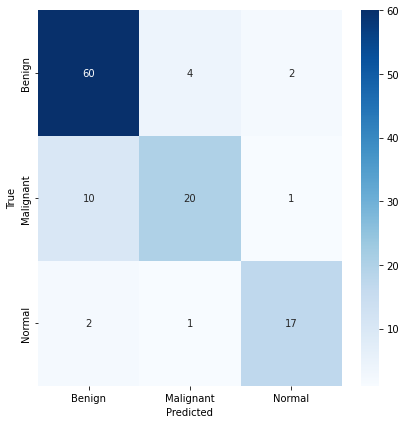

In [6]:
def test_model(
        model,
        test_loader,
        device,
        save_dir):

    os.makedirs(save_dir, exist_ok=True)

    vis_dir = os.path.join(
        save_dir,
        "visualizations"
    )

    os.makedirs(vis_dir, exist_ok=True)

    model.eval()

    all_gt = []
    all_pred = []

    results = []

    with torch.no_grad():

        for idx, batch in enumerate(
                tqdm(test_loader,
                     desc="Testing")):

            images = batch["image"].to(device)

            masks = batch["mask"].to(device)

            labels = batch["label"].to(device)

            pred_masks, logits = model(images)

            preds = torch.argmax(
                logits,
                dim=1
            )

            all_gt.extend(
                labels.cpu().numpy()
            )

            all_pred.extend(
                preds.cpu().numpy()
            )

            pred_masks = torch.sigmoid(
                pred_masks
            )

            pred_masks = (
                pred_masks > 0.5
            ).float()

            batch_size = images.size(0)

            for b in range(batch_size):

                gt_mask = masks[b,0].cpu().numpy()

                pred_mask = pred_masks[b,0].cpu().numpy()

                dice = dice_score(
                    pred_mask,
                    gt_mask
                )

                iou = iou_score(
                    pred_mask,
                    gt_mask
                )

                results.append({
                    "sample_id":
                    len(results),

                    "dice":
                    dice,

                    "iou":
                    iou
                })

                #################################################
                # Visualization
                #################################################

                image = images[b].cpu()

                image = image.permute(
                    1,2,0
                ).numpy()

                mean = np.array(
                    [0.485,0.456,0.406]
                )

                std = np.array(
                    [0.229,0.224,0.225]
                )

                image = image * std + mean

                image = np.clip(
                    image,
                    0,
                    1
                )

                overlay = image.copy()

                alpha = 0.4     # transparency

                red_mask = np.zeros_like(image)
                red_mask[:, :, 0] = 1.0   # Red color

                mask_region = pred_mask > 0

                overlay[mask_region] = (
                (1 - alpha) * image[mask_region]
                + alpha * red_mask[mask_region]
                    )

                overlay = np.clip(overlay, 0, 1)
                fig, ax = plt.subplots(
                    1,
                    4,
                    figsize=(16,4)
                )

                ax[0].imshow(image)
                ax[0].set_title(
                    "Original"
                )

                ax[1].imshow(
                    pred_mask,
                    cmap='gray'
                )
                ax[1].set_title(
                    "Predicted"
                )

                ax[2].imshow(
                    gt_mask,
                    cmap='gray'
                )
                ax[2].set_title(
                    "Ground Truth"
                )

                ax[3].imshow(
                    overlay
                )
                ax[3].set_title(
                    "Overlay"
                )

                for a in ax:
                    a.axis("off")

                plt.tight_layout()

                plt.savefig(
                    os.path.join(
                        vis_dir,
                        f"{len(results)}.png"
                    )
                )

                plt.close()

    #################################################
    # Classification metrics
    #################################################

    acc = accuracy_score(
        all_gt,
        all_pred
    )

    precision = precision_score(
        all_gt,
        all_pred,
        average='weighted'
    )

    recall = recall_score(
        all_gt,
        all_pred,
        average='weighted'
    )

    f1 = f1_score(
        all_gt,
        all_pred,
        average='weighted'
    )

    print(
        f"Accuracy : {acc:.4f}"
    )

    print(
        f"Precision : {precision:.4f}"
    )

    print(
        f"Recall : {recall:.4f}"
    )

    print(
        f"F1 : {f1:.4f}"
    )

    #################################################
    # Save CSV
    #################################################

    df = pd.DataFrame(
        results
    )

    df.to_csv(
        os.path.join(
            save_dir,
            "segmentation_metrics.csv"
        ),
        index=False
    )

    #################################################
    # Save classification metrics
    #################################################

    metrics_df = pd.DataFrame([{
        "accuracy": acc,
        "precision": precision,
        "recall": recall,
        "f1_score": f1
    }])

    metrics_df.to_csv(
        os.path.join(
            save_dir,
            "classification_metrics.csv"
        ),
        index=False
    )

    #################################################
    # Confusion Matrix
    #################################################

    cm = confusion_matrix(
        all_gt,
        all_pred
    )

    plt.figure(
        figsize=(6,6)
    )

    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        xticklabels=[
            "Benign",
            "Malignant",
            "Normal"
        ],
        yticklabels=[
            "Benign",
            "Malignant",
            "Normal"
        ]
    )

    plt.xlabel(
        "Predicted"
    )

    plt.ylabel(
        "True"
    )

    plt.tight_layout()

    plt.savefig(
        os.path.join(
            save_dir,
            "confusion_matrix.png"
        )
    )

    plt.show()
    
    
model.load_state_dict(
    torch.load(
        "Models/segformer/SegFormer_B2_BUSI_best.pth"
    )
)

model.to(device)

test_model(
    model=model,
    test_loader=test_loader,
    device=device,
    save_dir="Results"
)